In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import xgboost as xgb


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

#personal imputer
from utils.imputers import GroupwiseImputer


from sklearn.preprocessing import FunctionTransformer   
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


import sklearn
sklearn.set_config(display='diagram')

# Configure matplotlib for better display in Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.fancybox'] = True
plt.rcParams['legend.shadow'] = True

# Configure seaborn
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

In [4]:
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None  # Turn off pandas warnings

In [5]:
%cd "C:\00 ALL\05 Kaggle\02 Titanic"
df = pd.read_csv('train.csv')

C:\00 ALL\05 Kaggle\02 Titanic


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Start

In [8]:
columns_to_drop = ['PassengerId']
columns_to_use = [col for col in df.columns if col not in columns_to_drop]


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
for x in df.columns:
    print(f'{x} : {df[x].nunique()}')

PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


TODO: AGE is missing. We can fill it with the mean or median. Let's check the distribution of AGE.

In [12]:
columns_to_use

['Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

## PCLASS

In [64]:
df.Pclass.value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

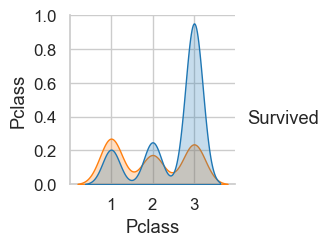

In [13]:
sns.pairplot(df[['Pclass','Survived']], hue='Survived')

## AGE

In [14]:
df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [15]:
df[df.Age.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


## CABIN

In [16]:
df['deck'] = df.Cabin.transform(lambda x: x.str[0])
df['deck'] = df['deck'].fillna('Unknown')



In [17]:
df.deck

0      Unknown
1            C
2      Unknown
3            C
4      Unknown
        ...   
886    Unknown
887          B
888    Unknown
889          C
890    Unknown
Name: deck, Length: 891, dtype: object

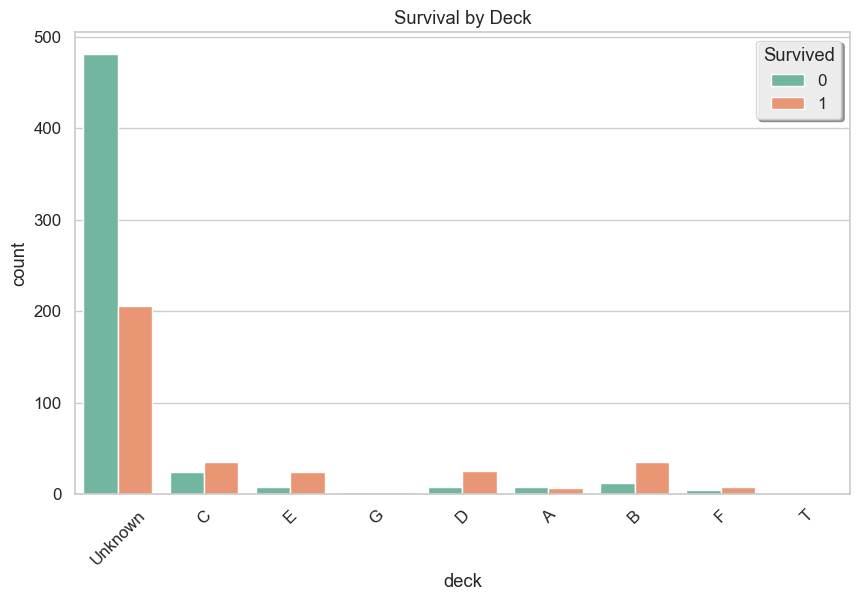

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='deck', hue='Survived', palette='Set2')
plt.title('Survival by Deck')
plt.xticks(rotation=45)
plt.show()

In [19]:
df.groupby(['deck'])['Survived'].value_counts()

deck     Survived
A        0             8
         1             7
B        1            35
         0            12
C        1            35
         0            24
D        1            25
         0             8
E        1            24
         0             8
F        1             8
         0             5
G        0             2
         1             2
T        0             1
Unknown  0           481
         1           206
Name: count, dtype: int64

In [20]:
df['title'] = df.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

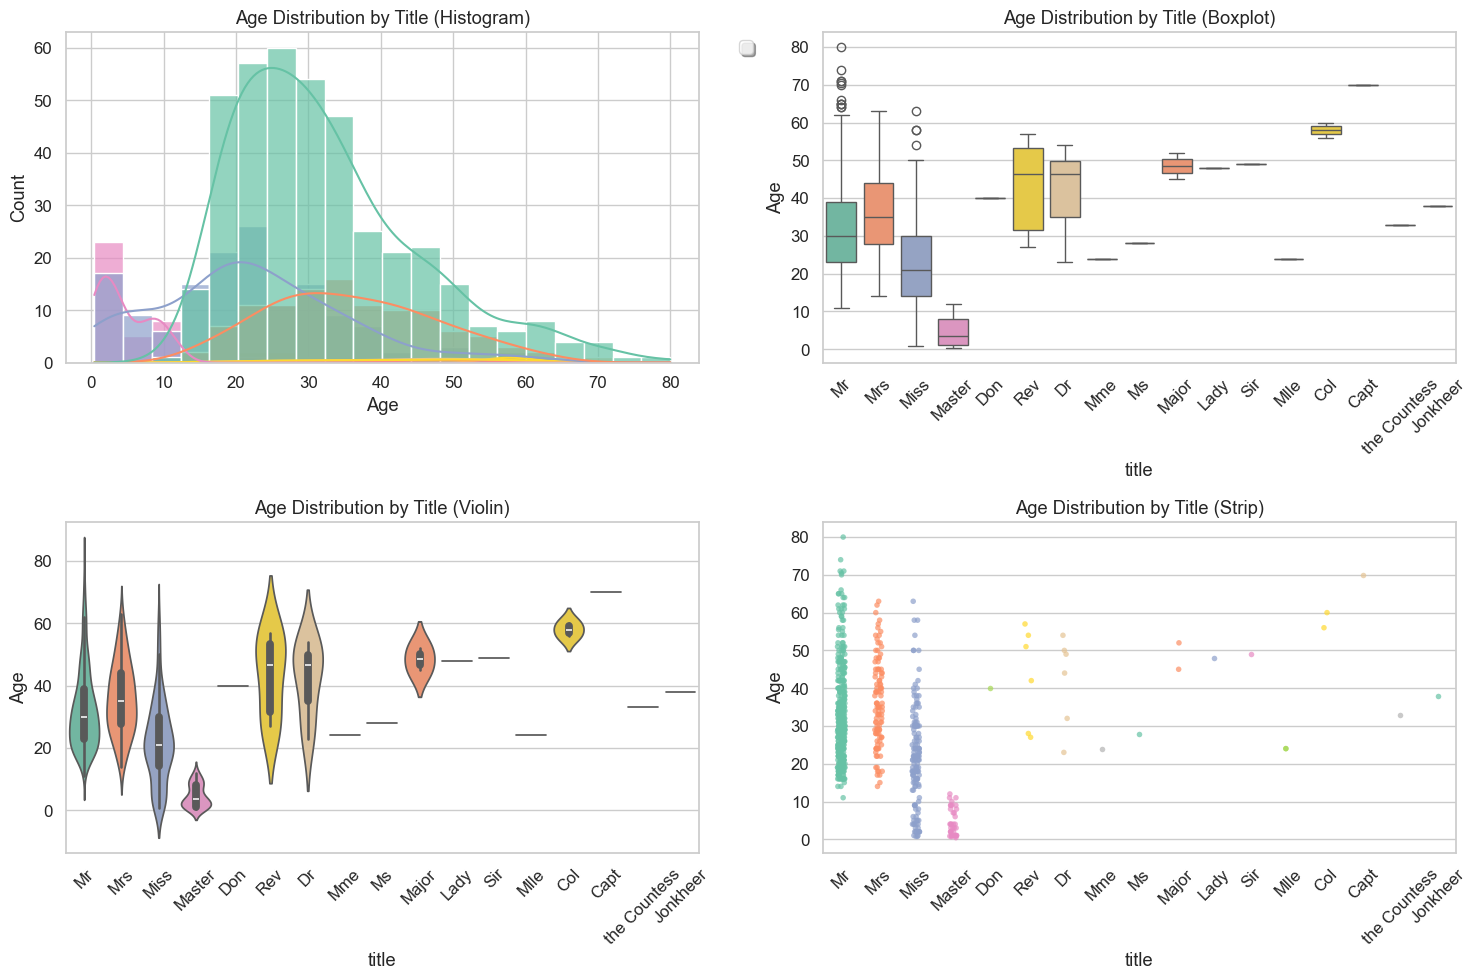

In [21]:
#visualize the title column
pd.options.mode.chained_assignment = None
# Age distribution by Title - multiple visualization approaches
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogram with title as hue
sns.histplot(data=df, x='Age', hue='title', palette='Set2', alpha=0.7, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Title (Histogram)')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Box plot
sns.boxplot(data=df, x='title', y='Age', hue='title', palette='Set2', legend=False, ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Title (Boxplot)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Violin plot
sns.violinplot(data=df, x='title', y='Age', hue='title', palette='Set2', legend=False, ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Title (Violin)')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Strip plot with jitter
sns.stripplot(data=df, x='title', y='Age', hue='title', palette='Set2', alpha=0.7, size=4, legend=False, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Title (Strip)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

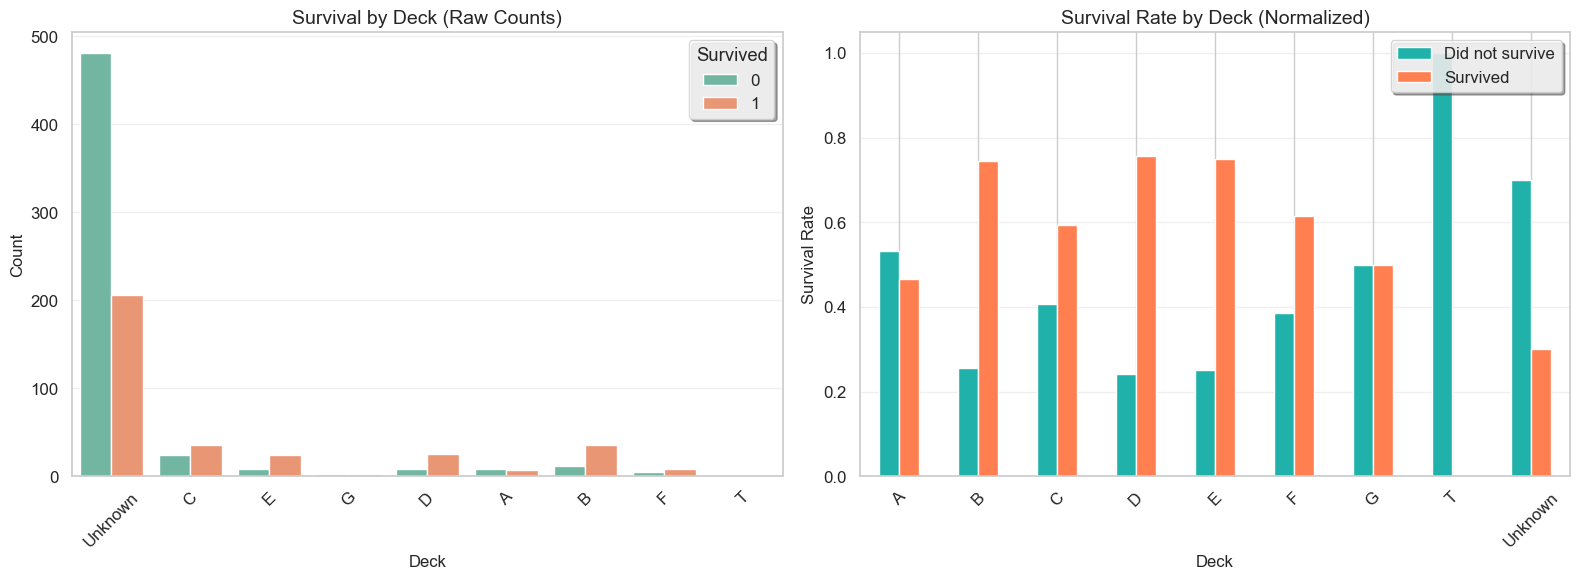

In [22]:

# Combined visualization: Raw counts and Normalized survival rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Left subplot: Raw counts
sns.countplot(data=df, x='deck', hue='Survived', palette='Set2', ax=ax1)
ax1.set_title('Survival by Deck (Raw Counts)', fontsize=14)
ax1.set_xlabel('Deck', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
# Right subplot: Normalized rates
deck_survival = df.groupby(['deck', 'Survived']).size().unstack(fill_value=0)
deck_survival_normalized = deck_survival.div(deck_survival.sum(axis=1), axis=0)
deck_survival_normalized.plot(kind='bar', stacked=False, 
                             color=[ 'lightseagreen','coral'], ax=ax2)
ax2.set_title('Survival Rate by Deck (Normalized)', fontsize=14)
ax2.set_xlabel('Deck', fontsize=12)
ax2.set_ylabel('Survival Rate', fontsize=12)
ax2.legend(['Did not survive', 'Survived'], loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
df['Age'] = df.groupby('title')['Age'].transform(lambda x: x.fillna(x.median()))


In [24]:
df.Age.isna().sum()

np.int64(0)

array([[<Axes: xlabel='PassengerId', ylabel='PassengerId'>,
        <Axes: xlabel='Survived', ylabel='PassengerId'>,
        <Axes: xlabel='Pclass', ylabel='PassengerId'>,
        <Axes: xlabel='Age', ylabel='PassengerId'>,
        <Axes: xlabel='SibSp', ylabel='PassengerId'>,
        <Axes: xlabel='Parch', ylabel='PassengerId'>,
        <Axes: xlabel='Fare', ylabel='PassengerId'>],
       [<Axes: xlabel='PassengerId', ylabel='Survived'>,
        <Axes: xlabel='Survived', ylabel='Survived'>,
        <Axes: xlabel='Pclass', ylabel='Survived'>,
        <Axes: xlabel='Age', ylabel='Survived'>,
        <Axes: xlabel='SibSp', ylabel='Survived'>,
        <Axes: xlabel='Parch', ylabel='Survived'>,
        <Axes: xlabel='Fare', ylabel='Survived'>],
       [<Axes: xlabel='PassengerId', ylabel='Pclass'>,
        <Axes: xlabel='Survived', ylabel='Pclass'>,
        <Axes: xlabel='Pclass', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass

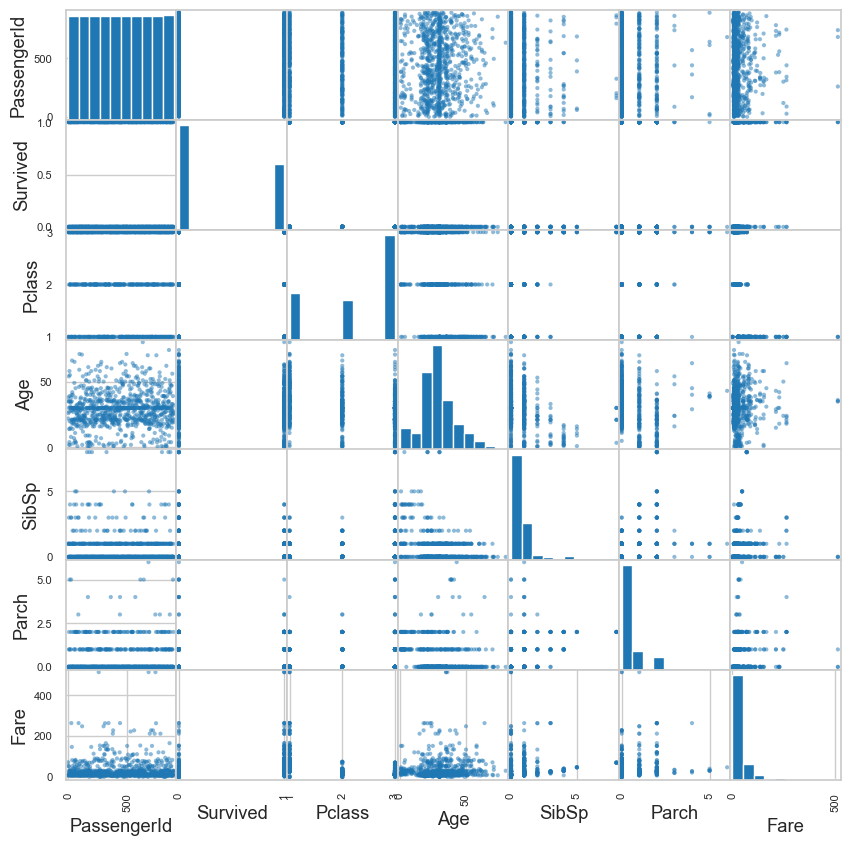

In [25]:
scatter_matrix(df, figsize=(10, 10))

# SibSb

In [26]:
df.SibSp.value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

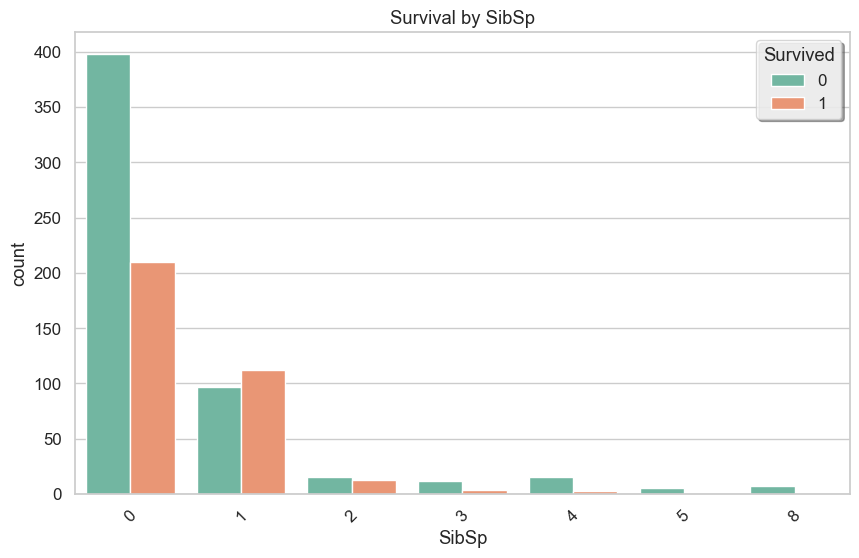

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SibSp', hue='Survived', palette='Set2')
plt.title('Survival by SibSp')
plt.xticks(rotation=45)
plt.show()

# Parch

In [34]:
df.Parch.value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

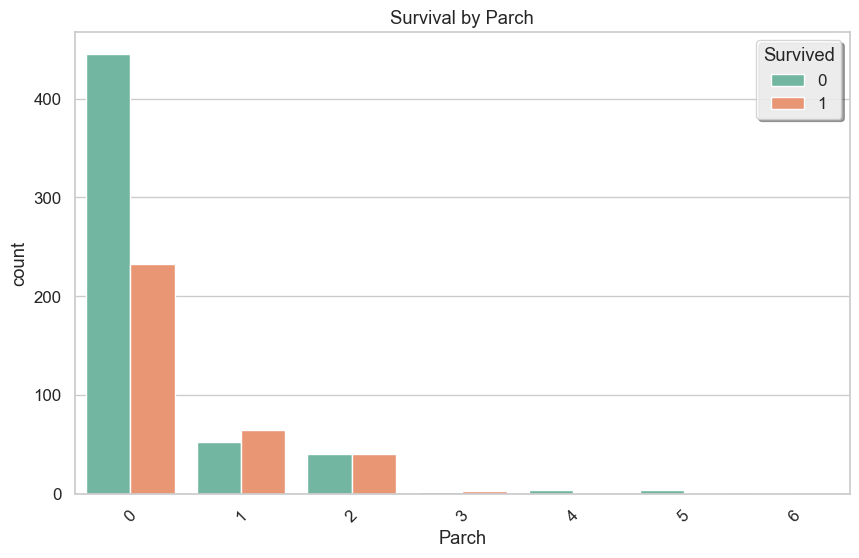

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Parch', hue='Survived', palette='Set2')
plt.title('Survival by Parch')
plt.xticks(rotation=45)
plt.show()

# Ticket

In [36]:
df.Ticket.value_counts()

Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
392091             1
Name: count, Length: 681, dtype: int64

In [40]:
df.Ticket.unique()[:5]

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450'],
      dtype=object)

In [44]:
df['ticket_prefix'] = df['Ticket'].str.extract(r'^([^0-9]*)')
df['ticket_prefix'] 

0          A/
1         PC 
2      STON/O
3            
4            
        ...  
886          
887          
888    W./C. 
889          
890          
Name: ticket_prefix, Length: 891, dtype: object

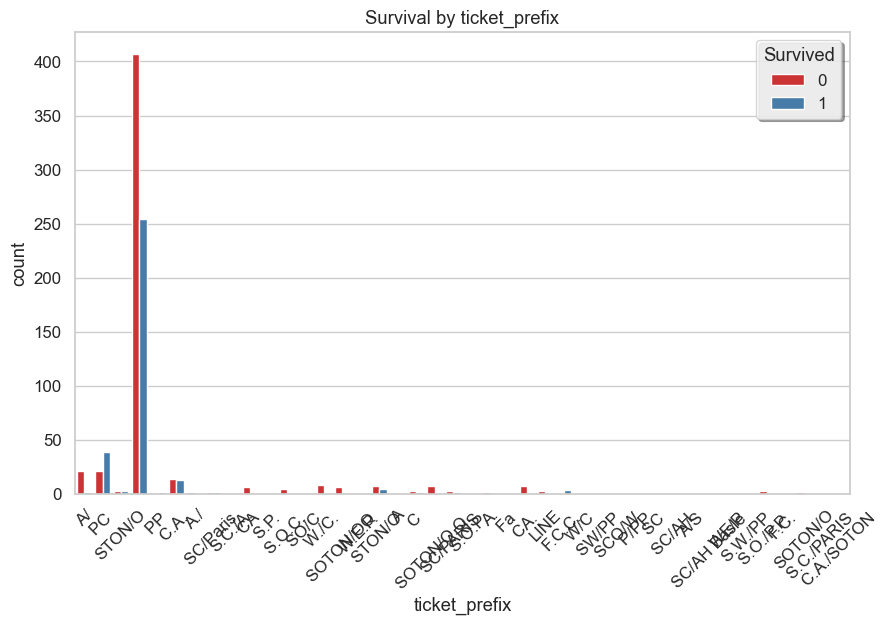

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='ticket_prefix', hue='Survived', palette='Set1')
plt.title('Survival by ticket_prefix')
plt.xticks(rotation=45)
plt.show()

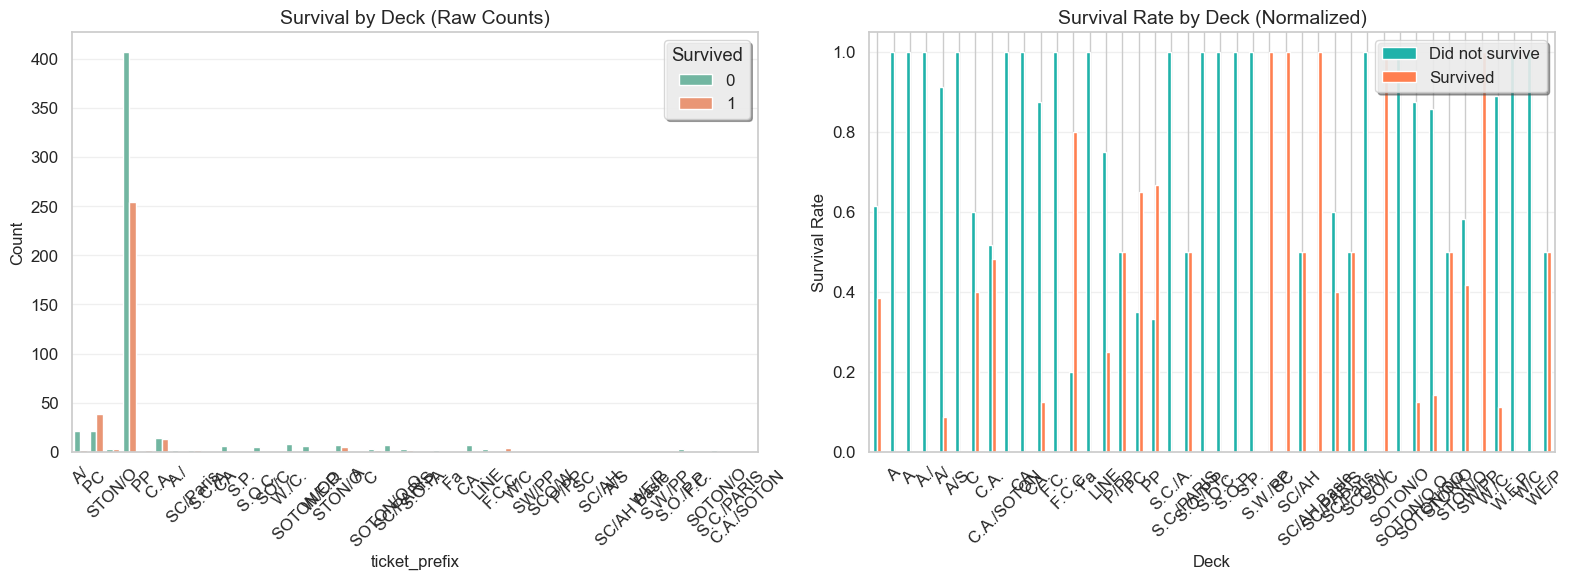

In [46]:
variable = 'ticket_prefix'
# Combined visualization: Raw counts and Normalized survival rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# Left subplot: Raw counts
sns.countplot(data=df, x=variable, hue='Survived', palette='Set2', ax=ax1)
ax1.set_title('Survival by Deck (Raw Counts)', fontsize=14)
ax1.set_xlabel(variable, fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
# Right subplot: Normalized rates
deck_survival = df.groupby([variable, 'Survived']).size().unstack(fill_value=0)
deck_survival_normalized = deck_survival.div(deck_survival.sum(axis=1), axis=0)
deck_survival_normalized.plot(kind='bar', stacked=False, 
                             color=[ 'lightseagreen','coral'], ax=ax2)
ax2.set_title('Survival Rate by Deck (Normalized)', fontsize=14)
ax2.set_xlabel('Deck', fontsize=12)
ax2.set_ylabel('Survival Rate', fontsize=12)
ax2.legend(['Did not survive', 'Survived'], loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Fare

In [47]:
df.Fare.describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

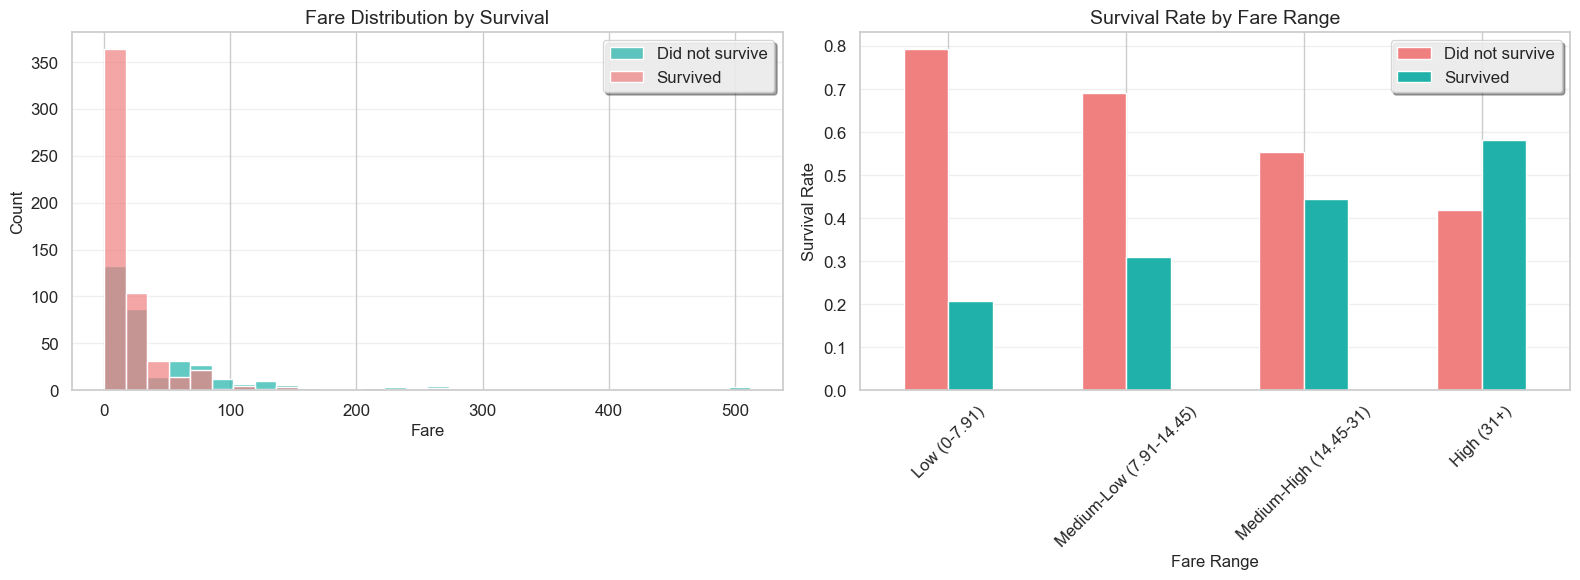

Fare Statistics by Survival:
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [49]:
variable = 'Fare'

# Create fare bins for better visualization
df['fare_binned'] = pd.cut(df[variable], 
                          bins=[0, 7.91, 14.45, 31, 512.33], 
                          labels=['Low (0-7.91)', 'Medium-Low (7.91-14.45)', 
                                  'Medium-High (14.45-31)', 'High (31+)'])

# Combined visualization: Distribution and Survival rates by fare bins
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left subplot: Histogram with survival overlay
sns.histplot(data=df, x=variable, hue='Survived', bins=30, 
             palette=['lightcoral', 'lightseagreen'], alpha=0.7, ax=ax1)
ax1.set_title('Fare Distribution by Survival', fontsize=14)
ax1.set_xlabel('Fare', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(['Did not survive', 'Survived'])

# Right subplot: Survival rates by fare bins
fare_survival = df.groupby(['fare_binned', 'Survived']).size().unstack(fill_value=0)
fare_survival_normalized = fare_survival.div(fare_survival.sum(axis=1), axis=0)
fare_survival_normalized.plot(kind='bar', stacked=False, 
                             color=['lightcoral', 'lightseagreen'], ax=ax2)
ax2.set_title('Survival Rate by Fare Range', fontsize=14)
ax2.set_xlabel('Fare Range', fontsize=12)
ax2.set_ylabel('Survival Rate', fontsize=12)
ax2.legend(['Did not survive', 'Survived'], loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional insight: Show fare statistics by survival
print("Fare Statistics by Survival:")
print(df.groupby('Survived')[variable].describe())

# Cabin

In [59]:
df['cabin_name'] = df.Cabin.str[0]
df['cabin_name'].value_counts()

cabin_name
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

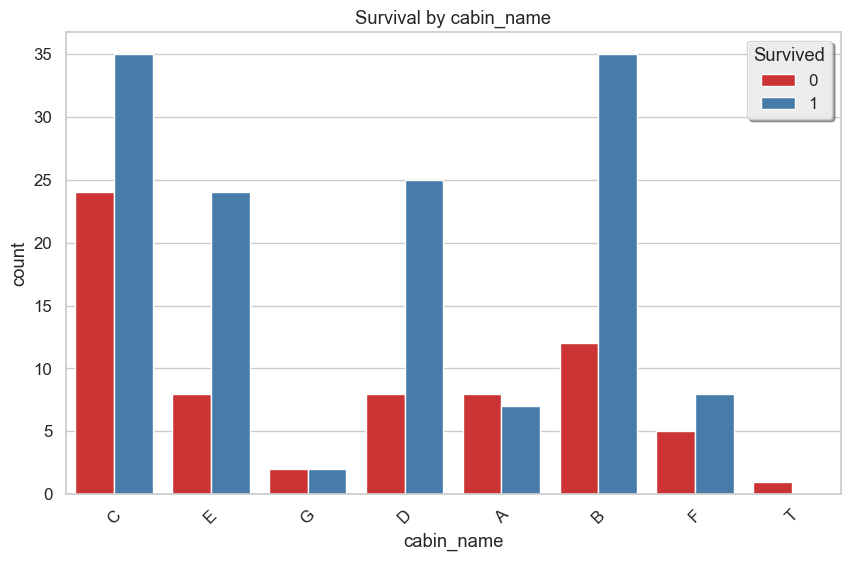

In [60]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cabin_name', hue='Survived', palette='Set1')
plt.title('Survival by cabin_name')
plt.xticks(rotation=45)
plt.show()

# Embarked

In [62]:
df.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

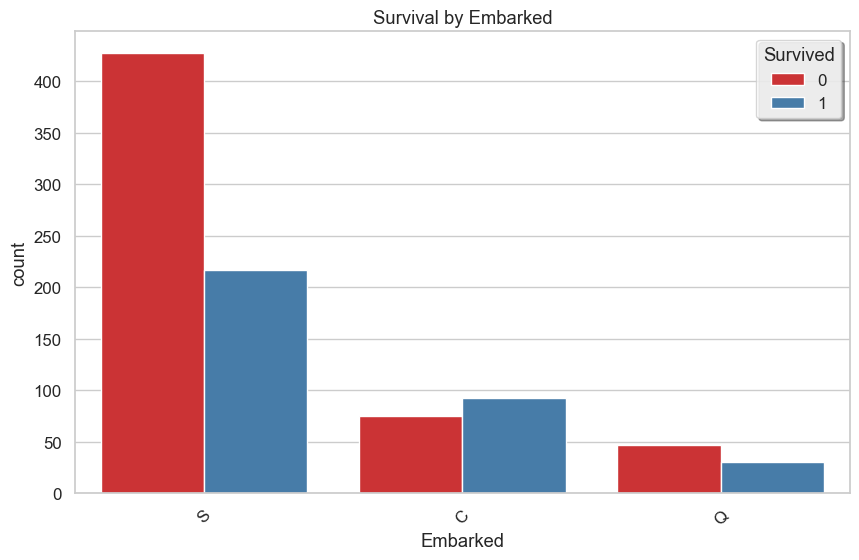

In [63]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Embarked', hue='Survived', palette='Set1')
plt.title('Survival by Embarked')
plt.xticks(rotation=45)
plt.show()